# 🛡️ Adversarial Attack & Defense — Model Training Pipeline

This notebook trains all models required for the **Bypassing Detection** project.  
It follows the same pipeline as `train_all.py` but provides **interactive, step-by-step execution** with visualizations.

### Pipeline Overview
| Step | Model | Description |
|------|-------|-------------|
| 1 | **Base CNN** | Standard MNIST classifier (~99% accuracy) |
| 2 | **Adversarially Trained** | Robust model via PGD adversarial training |
| 3 | **Distilled Model** | Teacher→Student with temperature scaling |
| 4 | **Detection Network** | Binary classifier on features (clean vs adversarial) |
| 5 | **Full Evaluation** | 4 attacks × 5 defenses = 20 combinations |

### Saved Outputs
- `saved_models/base_model.pth`
- `saved_models/adv_trained_model.pth`
- `saved_models/distilled_model.pth`
- `saved_models/detector_model.pth`
- `results/evaluation_results.json`

---

## 0 — Setup & Imports

In [8]:
import os
import sys
import time
import json

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt

# Ensure project root is on the path
PROJECT_ROOT = os.path.dirname(os.path.abspath("__file__"))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

# Project imports
from models.target_model import MNISTNet, DetectorNet
from defenses.adversarial_training import train_adversarial_model
from defenses.defensive_distillation import train_distilled_model
from defenses.detection_network import train_detector
from evaluation.evaluator import run_full_evaluation

# Create output directories
os.makedirs('saved_models', exist_ok=True)
os.makedirs('results', exist_ok=True)

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available:  {torch.cuda.is_available()}")

PyTorch version: 2.1.0a0+4136153
CUDA available:  True


In [4]:
# ── Device Selection ──
if torch.cuda.is_available():
    DEVICE = 'cuda'
    print(f"✅ Using GPU: {torch.cuda.get_device_name(0)}")
    print(f"   Memory: {torch.cuda.get_device_properties(0).total_mem / 1e9:.1f} GB")
else:
    DEVICE = 'cpu'
    print("⚠️  Using CPU — training will be slower")

print(f"\nDevice: {DEVICE}")

✅ Using GPU: NVIDIA H100 PCIe MIG 3g.40gb


AttributeError: 'torch._C._CudaDeviceProperties' object has no attribute 'total_mem'

---
## 1 — Load MNIST Dataset

In [9]:
BATCH_SIZE = 128

transform = transforms.Compose([
    transforms.ToTensor(),
])

train_dataset = datasets.MNIST(
    root='./data', train=True, download=True, transform=transform
)
test_dataset = datasets.MNIST(
    root='./data', train=False, download=True, transform=transform
)

train_loader = torch.utils.data.DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2
)
test_loader = torch.utils.data.DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2
)

print(f"✅ MNIST loaded")
print(f"   Training samples: {len(train_dataset):,}")
print(f"   Test samples:     {len(test_dataset):,}")
print(f"   Batch size:       {BATCH_SIZE}")
print(f"   Train batches:    {len(train_loader)}")

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 9912422/9912422 [00:02<00:00, 4467436.54it/s]


Extracting ./data/MNIST/raw/train-images-idx3-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 28881/28881 [00:00<00:00, 108006.82it/s]


Extracting ./data/MNIST/raw/train-labels-idx1-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 1648877/1648877 [00:01<00:00, 1051267.64it/s]


Extracting ./data/MNIST/raw/t10k-images-idx3-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 4542/4542 [00:00<00:00, 22491769.50it/s]

Extracting ./data/MNIST/raw/t10k-labels-idx1-ubyte.gz to ./data/MNIST/raw

✅ MNIST loaded
   Training samples: 60,000
   Test samples:     10,000
   Batch size:       128
   Train batches:    469



/usr/local/lib/python3.10/dist-packages/torch/utils/data/dataloader.py:560: UserWarning: This DataLoader will create 2 worker processes in total. Our suggested max number of worker in current system is 1, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(_create_warning_msg(


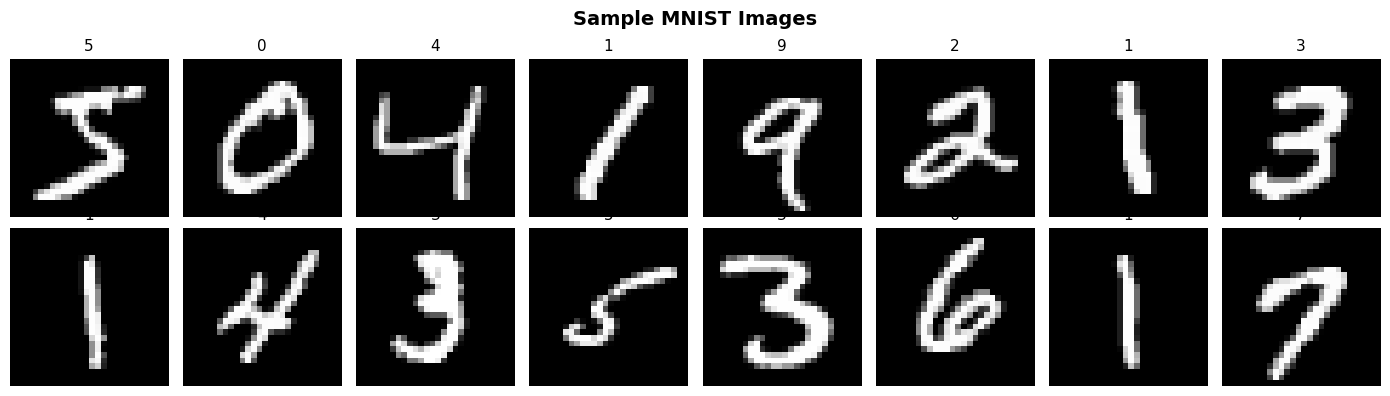

In [10]:
# ── Visualize sample images ──
fig, axes = plt.subplots(2, 8, figsize=(14, 4))
fig.suptitle('Sample MNIST Images', fontsize=14, fontweight='bold')
for i, ax in enumerate(axes.flat):
    image, label = train_dataset[i]
    ax.imshow(image.squeeze(), cmap='gray')
    ax.set_title(f'{label}', fontsize=11)
    ax.axis('off')
plt.tight_layout()
plt.show()

---
## Helper: Evaluate Model on Clean Data

In [11]:
def evaluate_model(model, test_loader, device=DEVICE, name="Model"):
    """Evaluate model accuracy on clean test data."""
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
    acc = 100.0 * correct / total
    print(f"  {name} — Clean Accuracy: {acc:.2f}%")
    return acc

---
## 2 — Train Base CNN Model

Standard MNIST classifier with:
- 4 convolutional layers (32→64 channels)
- BatchNorm + Dropout
- 2 fully connected layers
- Expected accuracy: **~99%**

In [12]:
# ── Hyperparameters ──
BASE_EPOCHS = 5
BASE_LR = 0.001

print("=" * 55)
print(" STEP 1: Training Base CNN Model")
print("=" * 55)
print(f"  Epochs: {BASE_EPOCHS}  |  LR: {BASE_LR}  |  Device: {DEVICE}")
print()

base_model = MNISTNet().to(DEVICE)
optimizer = optim.Adam(base_model.parameters(), lr=BASE_LR)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.5)

train_losses = []
train_accs = []
test_accs = []

start_time = time.time()

for epoch in range(BASE_EPOCHS):
    base_model.train()
    total_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)

        optimizer.zero_grad()
        outputs = base_model(images)
        loss = F.cross_entropy(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    scheduler.step()

    # Test accuracy
    base_model.eval()
    test_correct = 0
    test_total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs = base_model(images)
            _, predicted = outputs.max(1)
            test_total += labels.size(0)
            test_correct += predicted.eq(labels).sum().item()

    train_acc = 100.0 * correct / total
    test_acc = 100.0 * test_correct / test_total
    avg_loss = total_loss / len(train_loader)

    train_losses.append(avg_loss)
    train_accs.append(train_acc)
    test_accs.append(test_acc)

    print(f"  Epoch {epoch+1}/{BASE_EPOCHS} — "
          f"Loss: {avg_loss:.4f}  |  "
          f"Train: {train_acc:.2f}%  |  "
          f"Test: {test_acc:.2f}%")

elapsed = time.time() - start_time
print(f"\n  ✅ Base model trained in {elapsed:.1f}s — Test accuracy: {test_accs[-1]:.2f}%")

 STEP 1: Training Base CNN Model
  Epochs: 5  |  LR: 0.001  |  Device: cuda

  Epoch 1/5 — Loss: 0.2092  |  Train: 93.59%  |  Test: 98.36%
  Epoch 2/5 — Loss: 0.0729  |  Train: 97.80%  |  Test: 99.06%
  Epoch 3/5 — Loss: 0.0603  |  Train: 98.22%  |  Test: 99.16%
  Epoch 4/5 — Loss: 0.0390  |  Train: 98.88%  |  Test: 99.25%
  Epoch 5/5 — Loss: 0.0373  |  Train: 98.89%  |  Test: 99.17%

  ✅ Base model trained in 31.9s — Test accuracy: 99.17%


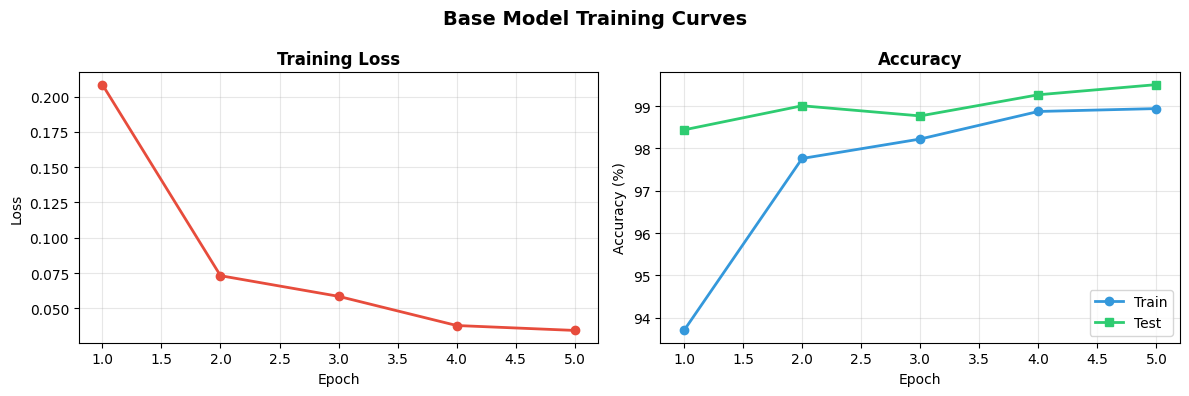

In [10]:
# ── Plot training curves ──
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

epochs_range = range(1, BASE_EPOCHS + 1)

ax1.plot(epochs_range, train_losses, 'o-', color='#e74c3c', linewidth=2, markersize=6)
ax1.set_title('Training Loss', fontweight='bold')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.grid(True, alpha=0.3)

ax2.plot(epochs_range, train_accs, 'o-', color='#3498db', linewidth=2, markersize=6, label='Train')
ax2.plot(epochs_range, test_accs, 's-', color='#2ecc71', linewidth=2, markersize=6, label='Test')
ax2.set_title('Accuracy', fontweight='bold')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.legend()
ax2.grid(True, alpha=0.3)

fig.suptitle('Base Model Training Curves', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [11]:
# ── Save base model ──
torch.save(base_model.state_dict(), 'saved_models/base_model.pth')
print("✅ Saved: saved_models/base_model.pth")

✅ Saved: saved_models/base_model.pth


---
## 3 — Adversarial Training (PGD)

**Proactive defense** — retrains the model with PGD-generated adversarial examples mixed into training data.

- Generates adversarial perturbations for **every training batch**
- Updates weights to minimize loss on adversarial inputs
- Most effective known defense against white-box attacks
- **Trade-off**: slightly lower clean accuracy, much higher robust accuracy

In [12]:
# ── Hyperparameters ──
ADV_EPSILON = 0.3       # L∞ perturbation bound
ADV_ALPHA = 0.01        # PGD step size
ADV_PGD_STEPS = 7       # PGD iterations per training batch
ADV_EPOCHS = 10
ADV_LR = 0.001

print("=" * 55)
print(" STEP 2: Adversarial Training Defense")
print("=" * 55)
print(f"  ε={ADV_EPSILON}  |  α={ADV_ALPHA}  |  "
      f"PGD steps={ADV_PGD_STEPS}  |  Epochs={ADV_EPOCHS}")
print()

start_time = time.time()

adv_model = train_adversarial_model(
    MNISTNet, train_loader,
    epsilon=ADV_EPSILON,
    alpha=ADV_ALPHA,
    pgd_steps=ADV_PGD_STEPS,
    epochs=ADV_EPOCHS,
    lr=ADV_LR,
    device=DEVICE
)

elapsed = time.time() - start_time
print(f"\n  ✅ Adversarial training completed in {elapsed:.1f}s")

 STEP 2: Adversarial Training Defense
  ε=0.3  |  α=0.01  |  PGD steps=7  |  Epochs=10


[Defense] Adversarial Training
  ε=0.3, α=0.01, PGD steps=7, epochs=10
  Epoch 1/10 — Loss: 0.3825, Robust Acc: 87.78%
  Epoch 2/10 — Loss: 0.1525, Robust Acc: 95.33%
  Epoch 3/10 — Loss: 0.1244, Robust Acc: 96.22%
  Epoch 4/10 — Loss: 0.1036, Robust Acc: 96.83%
  Epoch 5/10 — Loss: 0.0953, Robust Acc: 97.07%
  Epoch 6/10 — Loss: 0.0735, Robust Acc: 97.77%
  Epoch 7/10 — Loss: 0.0677, Robust Acc: 97.88%
  Epoch 8/10 — Loss: 0.0644, Robust Acc: 97.96%
  Epoch 9/10 — Loss: 0.0629, Robust Acc: 98.02%
  Epoch 10/10 — Loss: 0.0597, Robust Acc: 98.15%

  ✅ Adversarial training completed in 124.5s


In [13]:
# ── Save & evaluate ──
torch.save(adv_model.state_dict(), 'saved_models/adv_trained_model.pth')
print("✅ Saved: saved_models/adv_trained_model.pth")

adv_acc = evaluate_model(adv_model, test_loader, DEVICE, "Adversarial Model")
base_acc = evaluate_model(base_model, test_loader, DEVICE, "Base Model (reference)")
print(f"\n  Clean accuracy drop: {base_acc - adv_acc:.2f}% (expected trade-off)")

✅ Saved: saved_models/adv_trained_model.pth
  Adversarial Model — Clean Accuracy: 99.43%
  Base Model (reference) — Clean Accuracy: 99.51%

  Clean accuracy drop: 0.08% (expected trade-off)


---
## 4 — Defensive Distillation

**Proactive defense** — uses knowledge distillation with temperature scaling.

1. **Teacher** = the base model (already trained)
2. Generate **soft labels**: `softmax(logits / T)` with high temperature `T`
3. Train **student** on soft labels at temperature `T`
4. At inference, student uses `T=1`

The high temperature smooths the loss surface, reducing gradient magnitudes that gradient-based attackers rely on.

In [14]:
# ── Hyperparameters ──
DISTILL_TEMPERATURE = 20.0  # Higher = softer labels
DISTILL_ALPHA = 0.7         # Weight for distillation vs CE loss
DISTILL_EPOCHS = 10
DISTILL_LR = 0.001

print("=" * 55)
print(" STEP 3: Defensive Distillation")
print("=" * 55)
print(f"  Temperature={DISTILL_TEMPERATURE}  |  α={DISTILL_ALPHA}  |  "
      f"Epochs={DISTILL_EPOCHS}")
print()

start_time = time.time()

distilled_model = train_distilled_model(
    teacher_model=base_model,
    model_class=MNISTNet,
    train_loader=train_loader,
    temperature=DISTILL_TEMPERATURE,
    alpha=DISTILL_ALPHA,
    epochs=DISTILL_EPOCHS,
    lr=DISTILL_LR,
    device=DEVICE
)

elapsed = time.time() - start_time
print(f"\n  ✅ Distillation completed in {elapsed:.1f}s")

 STEP 3: Defensive Distillation
  Temperature=20.0  |  α=0.7  |  Epochs=10


[Defense] Defensive Distillation
  Temperature=20.0, α=0.7, epochs=10
  Epoch 1/10 — Loss: 4.0346, Clean Acc: 94.59%
  Epoch 2/10 — Loss: 2.4695, Clean Acc: 98.35%
  Epoch 3/10 — Loss: 2.3496, Clean Acc: 98.55%
  Epoch 4/10 — Loss: 2.2878, Clean Acc: 98.64%
  Epoch 5/10 — Loss: 2.2590, Clean Acc: 98.75%
  Epoch 6/10 — Loss: 2.1709, Clean Acc: 98.86%
  Epoch 7/10 — Loss: 2.1595, Clean Acc: 98.92%
  Epoch 8/10 — Loss: 2.1155, Clean Acc: 98.91%
  Epoch 9/10 — Loss: 2.1258, Clean Acc: 98.90%
  Epoch 10/10 — Loss: 2.1398, Clean Acc: 98.95%

  ✅ Distillation completed in 46.7s


In [15]:
# ── Save & evaluate ──
torch.save(distilled_model.state_dict(), 'saved_models/distilled_model.pth')
print("✅ Saved: saved_models/distilled_model.pth")

distilled_acc = evaluate_model(distilled_model, test_loader, DEVICE, "Distilled Model")
print(f"  Compared to base model: {distilled_acc - base_acc:+.2f}%")

✅ Saved: saved_models/distilled_model.pth
  Distilled Model — Clean Accuracy: 99.43%
  Compared to base model: -0.08%


---
## 5 — Detection Network

**Reactive defense** — trains a binary classifier on intermediate features to distinguish clean inputs from adversarial examples.

- Extracts features via `MNISTNet.get_features()` (flattened conv output: 3136-dim)
- Trains `DetectorNet` (3-layer MLP) on clean vs. adversarial features
- Adversarial features are generated using both **FGSM** and **PGD**
- At inference, detected adversarial inputs are **rejected** (not classified)

In [16]:
# ── Hyperparameters ──
DET_EPSILON = 0.3
DET_EPOCHS = 10
DET_LR = 0.001

print("=" * 55)
print(" STEP 4: Detection Network")
print("=" * 55)
print(f"  ε={DET_EPSILON}  |  Epochs={DET_EPOCHS}  |  LR={DET_LR}")
print()

start_time = time.time()

detector = DetectorNet()
detector = train_detector(
    target_model=base_model,
    detector_model=detector,
    train_loader=train_loader,
    epsilon=DET_EPSILON,
    epochs=DET_EPOCHS,
    lr=DET_LR,
    device=DEVICE
)

elapsed = time.time() - start_time
print(f"\n  ✅ Detector trained in {elapsed:.1f}s")

 STEP 4: Detection Network
  ε=0.3  |  Epochs=10  |  LR=0.001


[Defense] Training Detection Network
  Generating detection dataset...
  Detection dataset: 9984 samples (3968 clean, 6016 adversarial)
  Epoch 1/10 — Loss: 0.0559, Detection Acc: 99.20%
  Epoch 2/10 — Loss: 0.0065, Detection Acc: 99.99%
  Epoch 3/10 — Loss: 0.0030, Detection Acc: 100.00%
  Epoch 4/10 — Loss: 0.0017, Detection Acc: 100.00%
  Epoch 5/10 — Loss: 0.0012, Detection Acc: 100.00%
  Epoch 6/10 — Loss: 0.0009, Detection Acc: 100.00%
  Epoch 7/10 — Loss: 0.0007, Detection Acc: 100.00%
  Epoch 8/10 — Loss: 0.0006, Detection Acc: 100.00%
  Epoch 9/10 — Loss: 0.0005, Detection Acc: 100.00%
  Epoch 10/10 — Loss: 0.0004, Detection Acc: 100.00%

  ✅ Detector trained in 3.4s


In [17]:
# ── Save detector ──
torch.save(detector.state_dict(), 'saved_models/detector_model.pth')
print("✅ Saved: saved_models/detector_model.pth")

✅ Saved: saved_models/detector_model.pth


---
## 6 — Model Summary

Quick comparison of all trained models before running the full evaluation.

In [13]:
print("=" * 55)
print(" MODEL SUMMARY — Clean Accuracy Comparison")
print("=" * 55)
print()

results_summary = {}

for name, model in [('Base CNN', base_model),
                     ('Adversarially Trained', adv_model),
                     ('Distilled', distilled_model)]:
    acc = evaluate_model(model, test_loader, DEVICE, name)
    results_summary[name] = acc

print()

# Bar chart comparison
fig, ax = plt.subplots(figsize=(8, 4))
names = list(results_summary.keys())
accs = list(results_summary.values())
colors = ['#3498db', '#e74c3c', '#2ecc71']

bars = ax.bar(names, accs, color=colors, width=0.5, edgecolor='white', linewidth=1.5)
ax.set_ylim(90, 100)
ax.set_ylabel('Accuracy (%)', fontweight='bold')
ax.set_title('Clean Test Accuracy Comparison', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

for bar, acc in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.15,
            f'{acc:.2f}%', ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()

 MODEL SUMMARY — Clean Accuracy Comparison



NameError: name 'adv_model' is not defined

---
## 7 — Full Evaluation (4 Attacks × 5 Defenses)

Evaluates all **20 attack–defense combinations**:

| | No Defense | Adv. Training | Input Transform | Detection | Distillation |
|---|---|---|---|---|---|
| **FGSM** | ✓ | ✓ | ✓ | ✓ | ✓ |
| **PGD** | ✓ | ✓ | ✓ | ✓ | ✓ |
| **Genetic Alg.** | ✓ | ✓ | ✓ | ✓ | ✓ |
| **Diff. Evolution** | ✓ | ✓ | ✓ | ✓ | ✓ |

> **Note**: Evolutionary computation attacks (Genetic Algorithm, Differential Evolution) are slower because they operate per-image.

In [15]:
# ── Evaluation parameters ──
EVAL_EPSILON = 0.3
EVAL_NUM_SAMPLES = 50   # Use 50 for speed; increase for more reliable results

print("=" * 55)
print(" STEP 5: Full Evaluation (4 attacks × 5 defenses)")
print("=" * 55)
print(f"  Epsilon: {EVAL_EPSILON}")
print(f"  Samples: {EVAL_NUM_SAMPLES}")
print(f"  Note: EC attacks (GA, DE) are slower — evaluating on {EVAL_NUM_SAMPLES} samples")
print()

models_dict = {
    'base': base_model,
    'adv_trained': adv_model,
    'distilled': distilled_model,
    'detector': detector,
}

start_time = time.time()

eval_results = run_full_evaluation(
    models_dict=models_dict,
    test_loader=test_loader,
    epsilon=EVAL_EPSILON,
    num_samples=EVAL_NUM_SAMPLES,
    device=DEVICE,
    save_path='results/evaluation_results.json'
)

elapsed = time.time() - start_time
print(f"\n  ✅ Evaluation completed in {elapsed/60:.1f} minutes")

 STEP 5: Full Evaluation (4 attacks × 5 defenses)
  Epsilon: 0.3
  Samples: 50
  Note: EC attacks (GA, DE) are slower — evaluating on 50 samples



NameError: name 'adv_model' is not defined

---
## 8 — Results Visualization

In [14]:
# ── Load results ──
with open('results/evaluation_results.json', 'r') as f:
    results = json.load(f)

attack_display = results['attack_names']
defense_display = results['defense_names']
matrix = results['results']

# ── Print results table ──
print("\n" + "=" * 80)
print(" ATTACK SUCCESS RATE (%) — Lower is better for defenses")
print("=" * 80)
print(f"{'Attack':<28}", end='')
for dk in defense_display:
    print(f"{defense_display[dk]:>14}", end='')
print()
print("-" * 80)
for ak in attack_display:
    print(f"{attack_display[ak]:<28}", end='')
    for dk in defense_display:
        if dk in matrix.get(ak, {}):
            asr = matrix[ak][dk].get('attack_success_rate', 'N/A')
            print(f"{asr:>13.1f}%", end='')
        else:
            print(f"{'N/A':>14}", end='')
    print()

print("\n" + "=" * 80)
print(" ROBUST ACCURACY (%) — Higher is better for defenses")
print("=" * 80)
print(f"{'Attack':<28}", end='')
for dk in defense_display:
    print(f"{defense_display[dk]:>14}", end='')
print()
print("-" * 80)
for ak in attack_display:
    print(f"{attack_display[ak]:<28}", end='')
    for dk in defense_display:
        if dk in matrix.get(ak, {}):
            rob = matrix[ak][dk].get('robust_accuracy', 'N/A')
            print(f"{rob:>13.1f}%", end='')
        else:
            print(f"{'N/A':>14}", end='')
    print()

FileNotFoundError: [Errno 2] No such file or directory: 'results/evaluation_results.json'

In [ ]:
# ── Heatmap: Attack Success Rate ──
attack_keys = list(attack_display.keys())
defense_keys = list(defense_display.keys())

asr_matrix = np.zeros((len(attack_keys), len(defense_keys)))
for i, ak in enumerate(attack_keys):
    for j, dk in enumerate(defense_keys):
        if dk in matrix.get(ak, {}):
            asr_matrix[i, j] = matrix[ak][dk].get('attack_success_rate', 0)

fig, ax = plt.subplots(figsize=(10, 5))
im = ax.imshow(asr_matrix, cmap='RdYlGn_r', aspect='auto', vmin=0, vmax=100)

ax.set_xticks(range(len(defense_keys)))
ax.set_xticklabels([defense_display[k] for k in defense_keys], rotation=30, ha='right')
ax.set_yticks(range(len(attack_keys)))
ax.set_yticklabels([attack_display[k] for k in attack_keys])

# Add value annotations
for i in range(len(attack_keys)):
    for j in range(len(defense_keys)):
        val = asr_matrix[i, j]
        color = 'white' if val > 60 else 'black'
        ax.text(j, i, f'{val:.1f}%', ha='center', va='center',
                fontsize=11, fontweight='bold', color=color)

ax.set_title('Attack Success Rate (%) — Lower = Better Defense',
             fontsize=14, fontweight='bold', pad=15)
plt.colorbar(im, ax=ax, label='ASR (%)')
plt.tight_layout()
plt.show()

In [ ]:
# ── Grouped bar chart: Robust Accuracy per attack ──
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(attack_keys))
width = 0.15
colors = ['#e74c3c', '#3498db', '#f39c12', '#9b59b6', '#2ecc71']

for j, dk in enumerate(defense_keys):
    robust_accs = []
    for ak in attack_keys:
        if dk in matrix.get(ak, {}):
            robust_accs.append(matrix[ak][dk].get('robust_accuracy', 0))
        else:
            robust_accs.append(0)
    offset = (j - len(defense_keys)/2 + 0.5) * width
    ax.bar(x + offset, robust_accs, width, label=defense_display[dk],
           color=colors[j % len(colors)], edgecolor='white', linewidth=0.5)

ax.set_xticks(x)
ax.set_xticklabels([attack_display[k] for k in attack_keys])
ax.set_ylabel('Robust Accuracy (%)', fontweight='bold')
ax.set_title('Robust Accuracy by Attack & Defense',
             fontsize=14, fontweight='bold')
ax.legend(loc='upper right', fontsize=9)
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0, 105)
plt.tight_layout()
plt.show()

---
## 9 — Final Summary

In [ ]:
print("\n" + "=" * 55)
print(" ✅ ALL TRAINING COMPLETE")
print("=" * 55)
print()
print("Saved models:")
for f in ['saved_models/base_model.pth',
          'saved_models/adv_trained_model.pth',
          'saved_models/distilled_model.pth',
          'saved_models/detector_model.pth']:
    size = os.path.getsize(f) / 1024 if os.path.exists(f) else 0
    print(f"  • {f:<42} ({size:.0f} KB)")

print()
print("Evaluation results:")
print("  • results/evaluation_results.json")
print()
print("Next steps:")
print("  • Run the web interface:  python app.py")
print("  • Open in browser:        http://localhost:5000")